In [ ]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

import os

# Styling
plt.style.use('seaborn-v0_8')

sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['font.size'] = 12

print("🔍 DATA UNDERSTANDING PHASE")
print("="*60)

🔍 DATA UNDERSTANDING PHASE


In [34]:
# =====================================================
# LOAD DATASET
# =====================================================

print("\n📂 LOADING DATASET")
print("="*40)

df = pd.read_excel(
    "../dataset/raw/emdat-country-profiles_idn_2026_05_23.xlsx"
)

# Hapus baris metadata EM-DAT
df = df.iloc[1:].reset_index(drop=True)

print("✅ Dataset Loaded Successfully")
print(f"Shape : {df.shape}")

display(df.head())


📂 LOADING DATASET
✅ Dataset Loaded Successfully
Shape : (158, 13)


,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
0,2000,Indonesia,IDN,Natural,Climatological,Wildfire,Forest fire,1,NaN,NaN,NaN,NaN,53.487737
1,2000,Indonesia,IDN,Natural,Geophysical,Earthquake,Ground movement,5,270108,149,73000000.0,136479882,53.487737
2,2000,Indonesia,IDN,Natural,Hydrological,Flood,Flash flood,2,89852,164,79000000.0,147697407,53.487737
3,2000,Indonesia,IDN,Natural,Hydrological,Flood,Riverine flood,1,386021,100,34000000.0,63565973,53.487737
4,2000,Indonesia,IDN,Natural,Hydrological,Mass movement (wet),Landslide (wet),2,539,52,NaN,NaN,53.487737


In [35]:
print("\n📊 BASIC INFORMATION")
print("="*40)

numeric_cols = [
    'Year',
    'Total Events',
    'Total Affected',
    'Total Deaths',
    'Total Damage (USD, original)',
    'Total Damage (USD, adjusted)',
    'CPI'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

print(df.info())

print("\n📋 DATA TYPES")

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes,
    "Unique Values":[df[col].nunique() for col in df.columns]
})

display(dtype_df)


📊 BASIC INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          158 non-null    int64  
 1   Country                       158 non-null    str    
 2   ISO                           158 non-null    str    
 3   Disaster Group                158 non-null    str    
 4   Disaster Subroup              158 non-null    str    
 5   Disaster Type                 158 non-null    str    
 6   Disaster Subtype              158 non-null    str    
 7   Total Events                  158 non-null    int64  
 8   Total Affected                149 non-null    float64
 9   Total Deaths                  127 non-null    float64
 10  Total Damage (USD, original)  56 non-null     float64
 11  Total Damage (USD, adjusted)  55 non-null     float64
 12  CPI                           153 non-null    float64


,Column,Datatype,Unique Values
Year,Year,int64,27
Country,Country,str,1
ISO,ISO,str,1
Disaster Group,Disaster Group,str,1
Disaster Subroup,Disaster Subroup,str,4
Disaster Type,Disaster Type,str,7
Disaster Subtype,Disaster Subtype,str,19
Total Events,Total Events,int64,13
Total Affected,Total Affected,float64,147
Total Deaths,Total Deaths,float64,82



🔍 DATA QUALITY CHECK


,Missing Count,Percentage
Year,0,0.000000
Country,0,0.000000
ISO,0,0.000000
Disaster Group,0,0.000000
Disaster Subroup,0,0.000000
Disaster Type,0,0.000000
Disaster Subtype,0,0.000000
Total Events,0,0.000000
Total Affected,9,5.696203
Total Deaths,31,19.620253


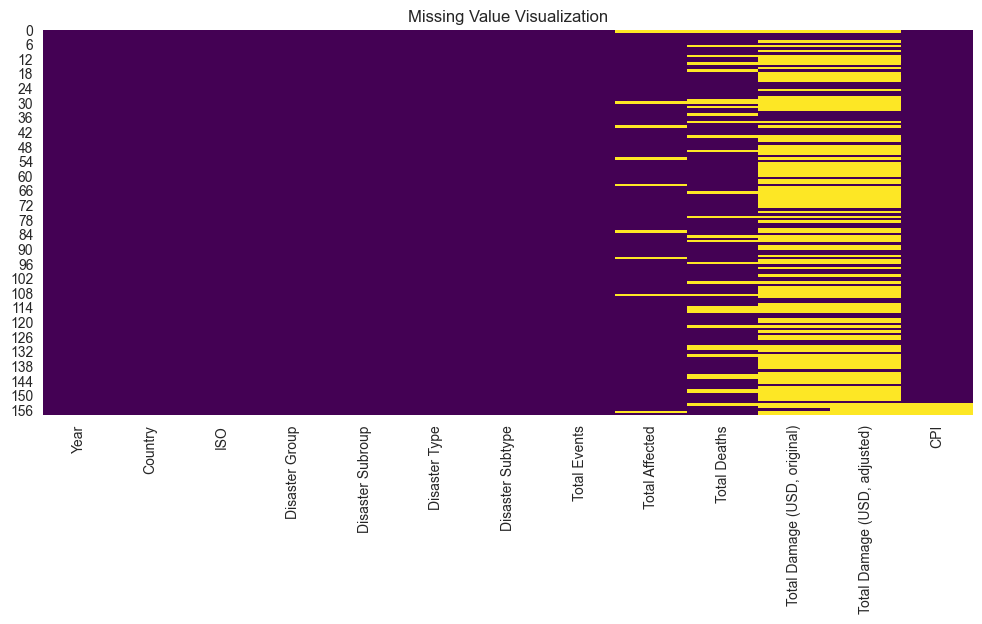

Duplicate Rows : 0


In [36]:
print("\n🔍 DATA QUALITY CHECK")
print("="*40)

# Missing Value
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Percentage":
    (df.isnull().sum()/len(df))*100
})

display(missing)

# Visualisasi Missing Value
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title(
    "Missing Value Visualization"
)

plt.savefig(
    '../reports/figures/1_missing_value.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Duplicate Check
duplicates = df.duplicated().sum()

print(
    f"Duplicate Rows : {duplicates}"
)

In [37]:
print("\n📈 DESCRIPTIVE STATISTICS")
print("="*40)

display(
    df.describe(include='all')
)


📈 DESCRIPTIVE STATISTICS


,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
count,158.000000,158,158,158,158,158,158,158.000000,1.490000e+02,127.000000,5.600000e+01,5.500000e+01,153.000000
unique,NaN,1,1,1,4,7,19,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Indonesia,IDN,Natural,Hydrological,Flood,Ground movement,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,158,158,158,83,54,26,NaN,NaN,NaN,NaN,NaN,NaN
mean,2013.278481,NaN,NaN,NaN,NaN,NaN,NaN,2.620253,3.155249e+05,1494.559055,4.917235e+08,7.053898e+08,73.127280
std,7.888453,NaN,NaN,NaN,NaN,NaN,NaN,2.545403,1.604181e+06,14701.532001,1.004762e+09,1.471444e+09,13.200038
min,2000.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,3.000000e+00,1.000000,1.000000e+06,1.402228e+06,53.487737
25%,2006.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,2.035000e+03,11.000000,1.800000e+07,2.144217e+07,62.617195
50%,2013.500000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.300000e+04,45.000000,6.100000e+07,8.783530e+07,72.359737
75%,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.204640e+05,120.500000,2.754000e+08,4.749115e+08,80.390383



 NUMERICAL FEATURE ANALYSIS


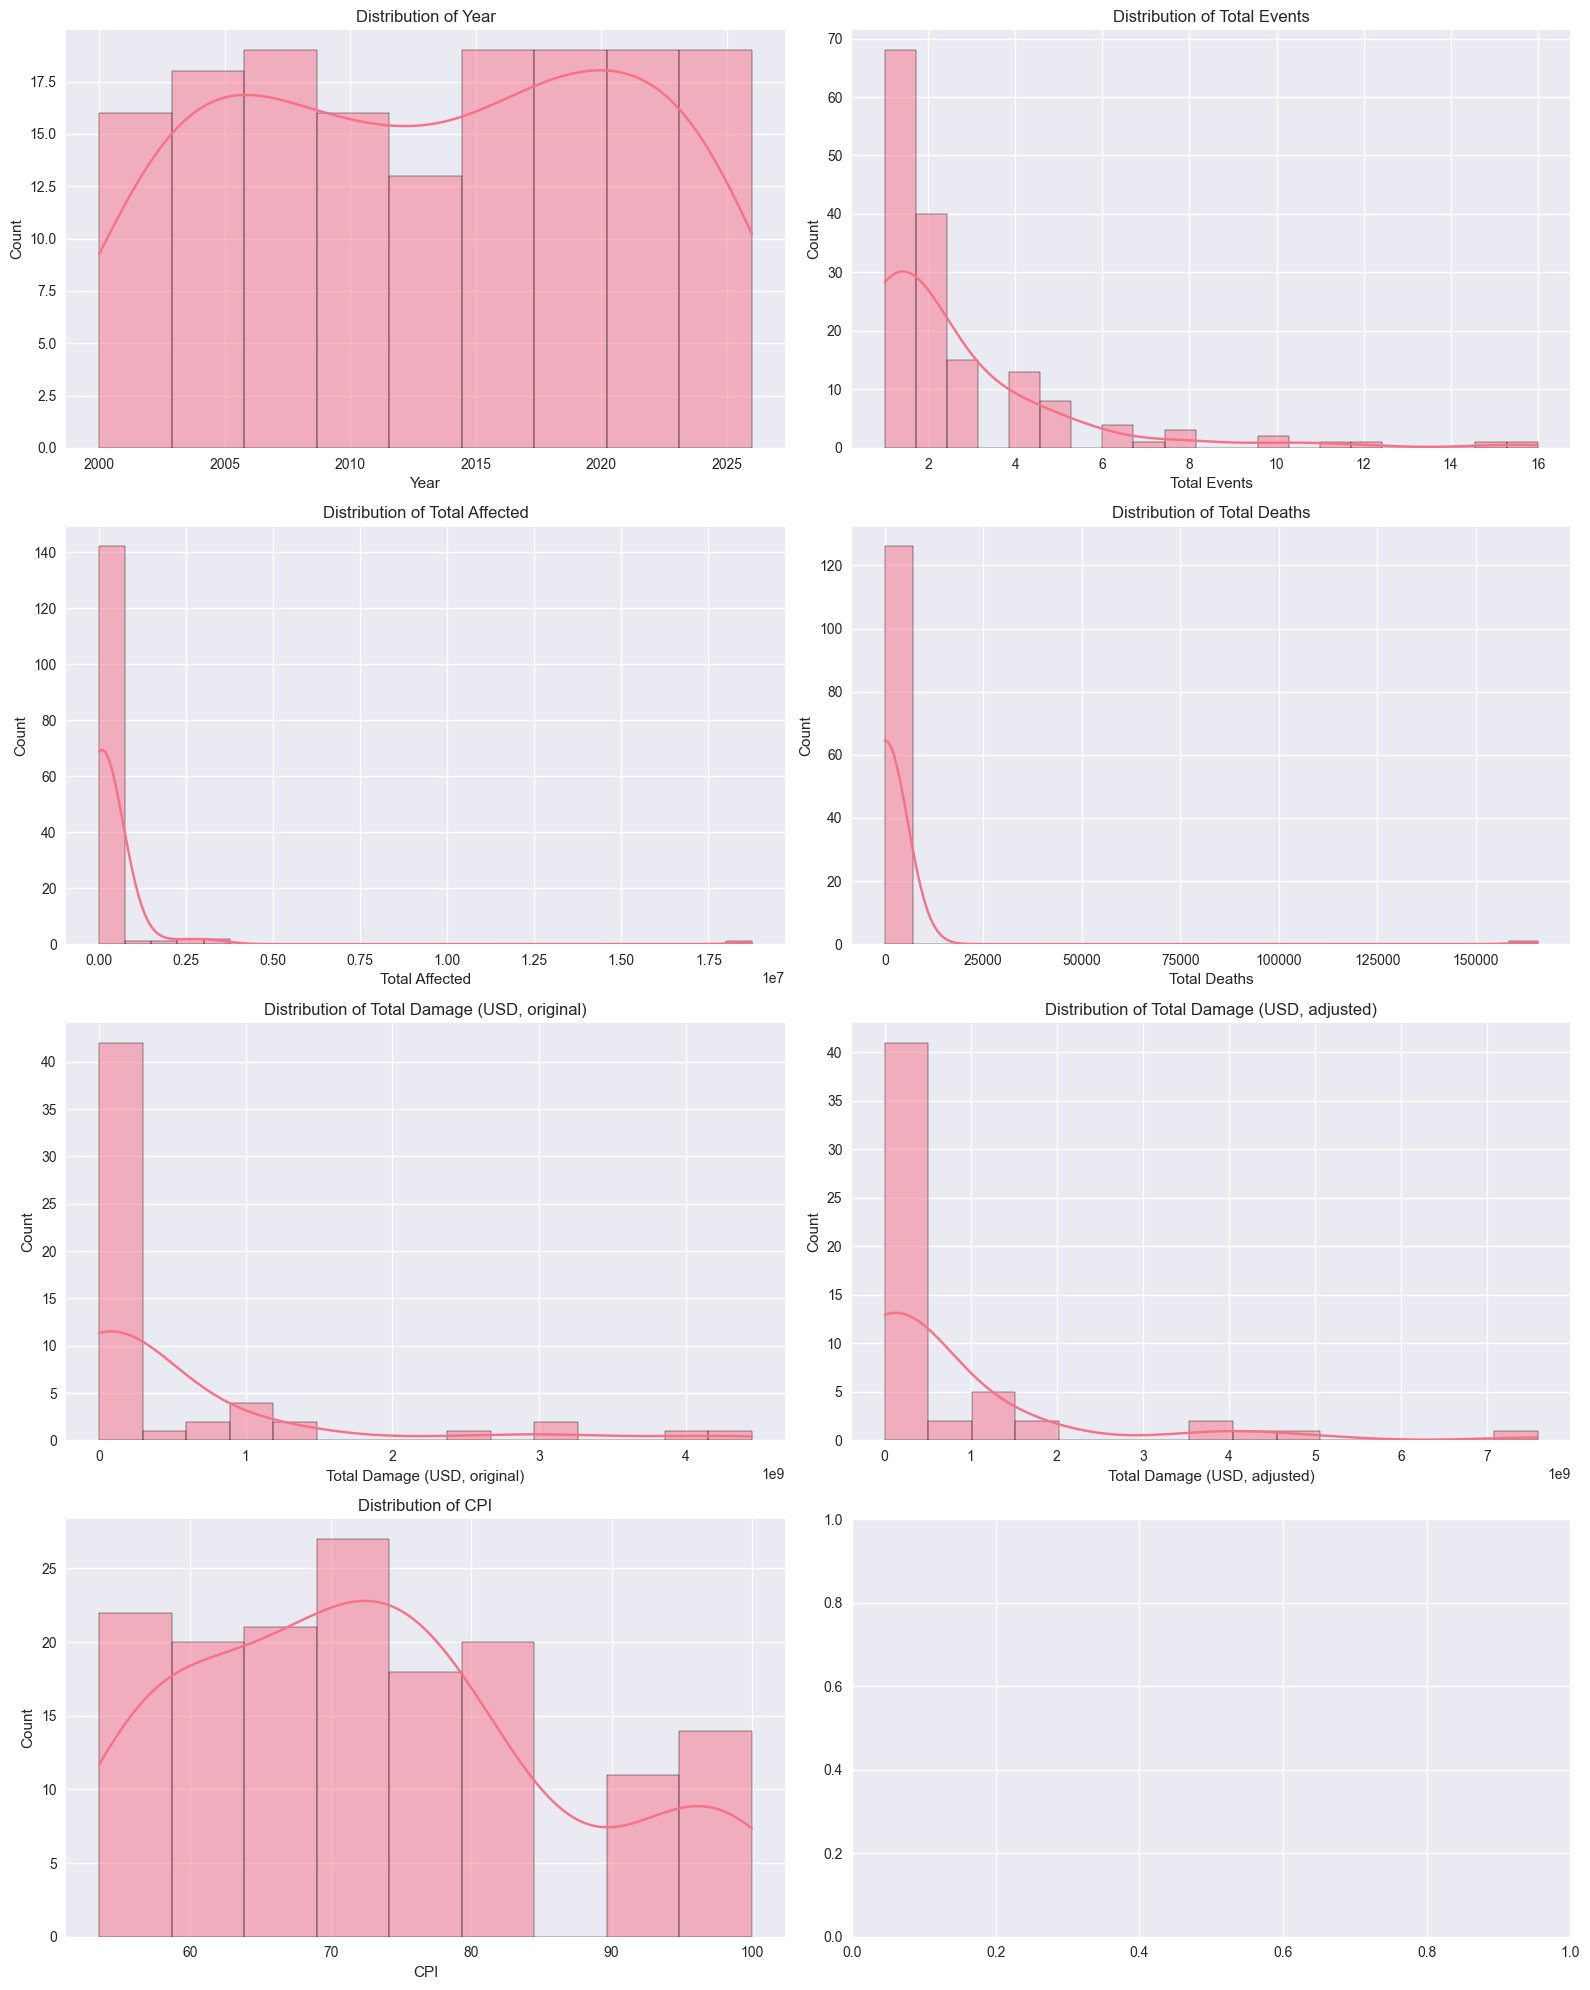

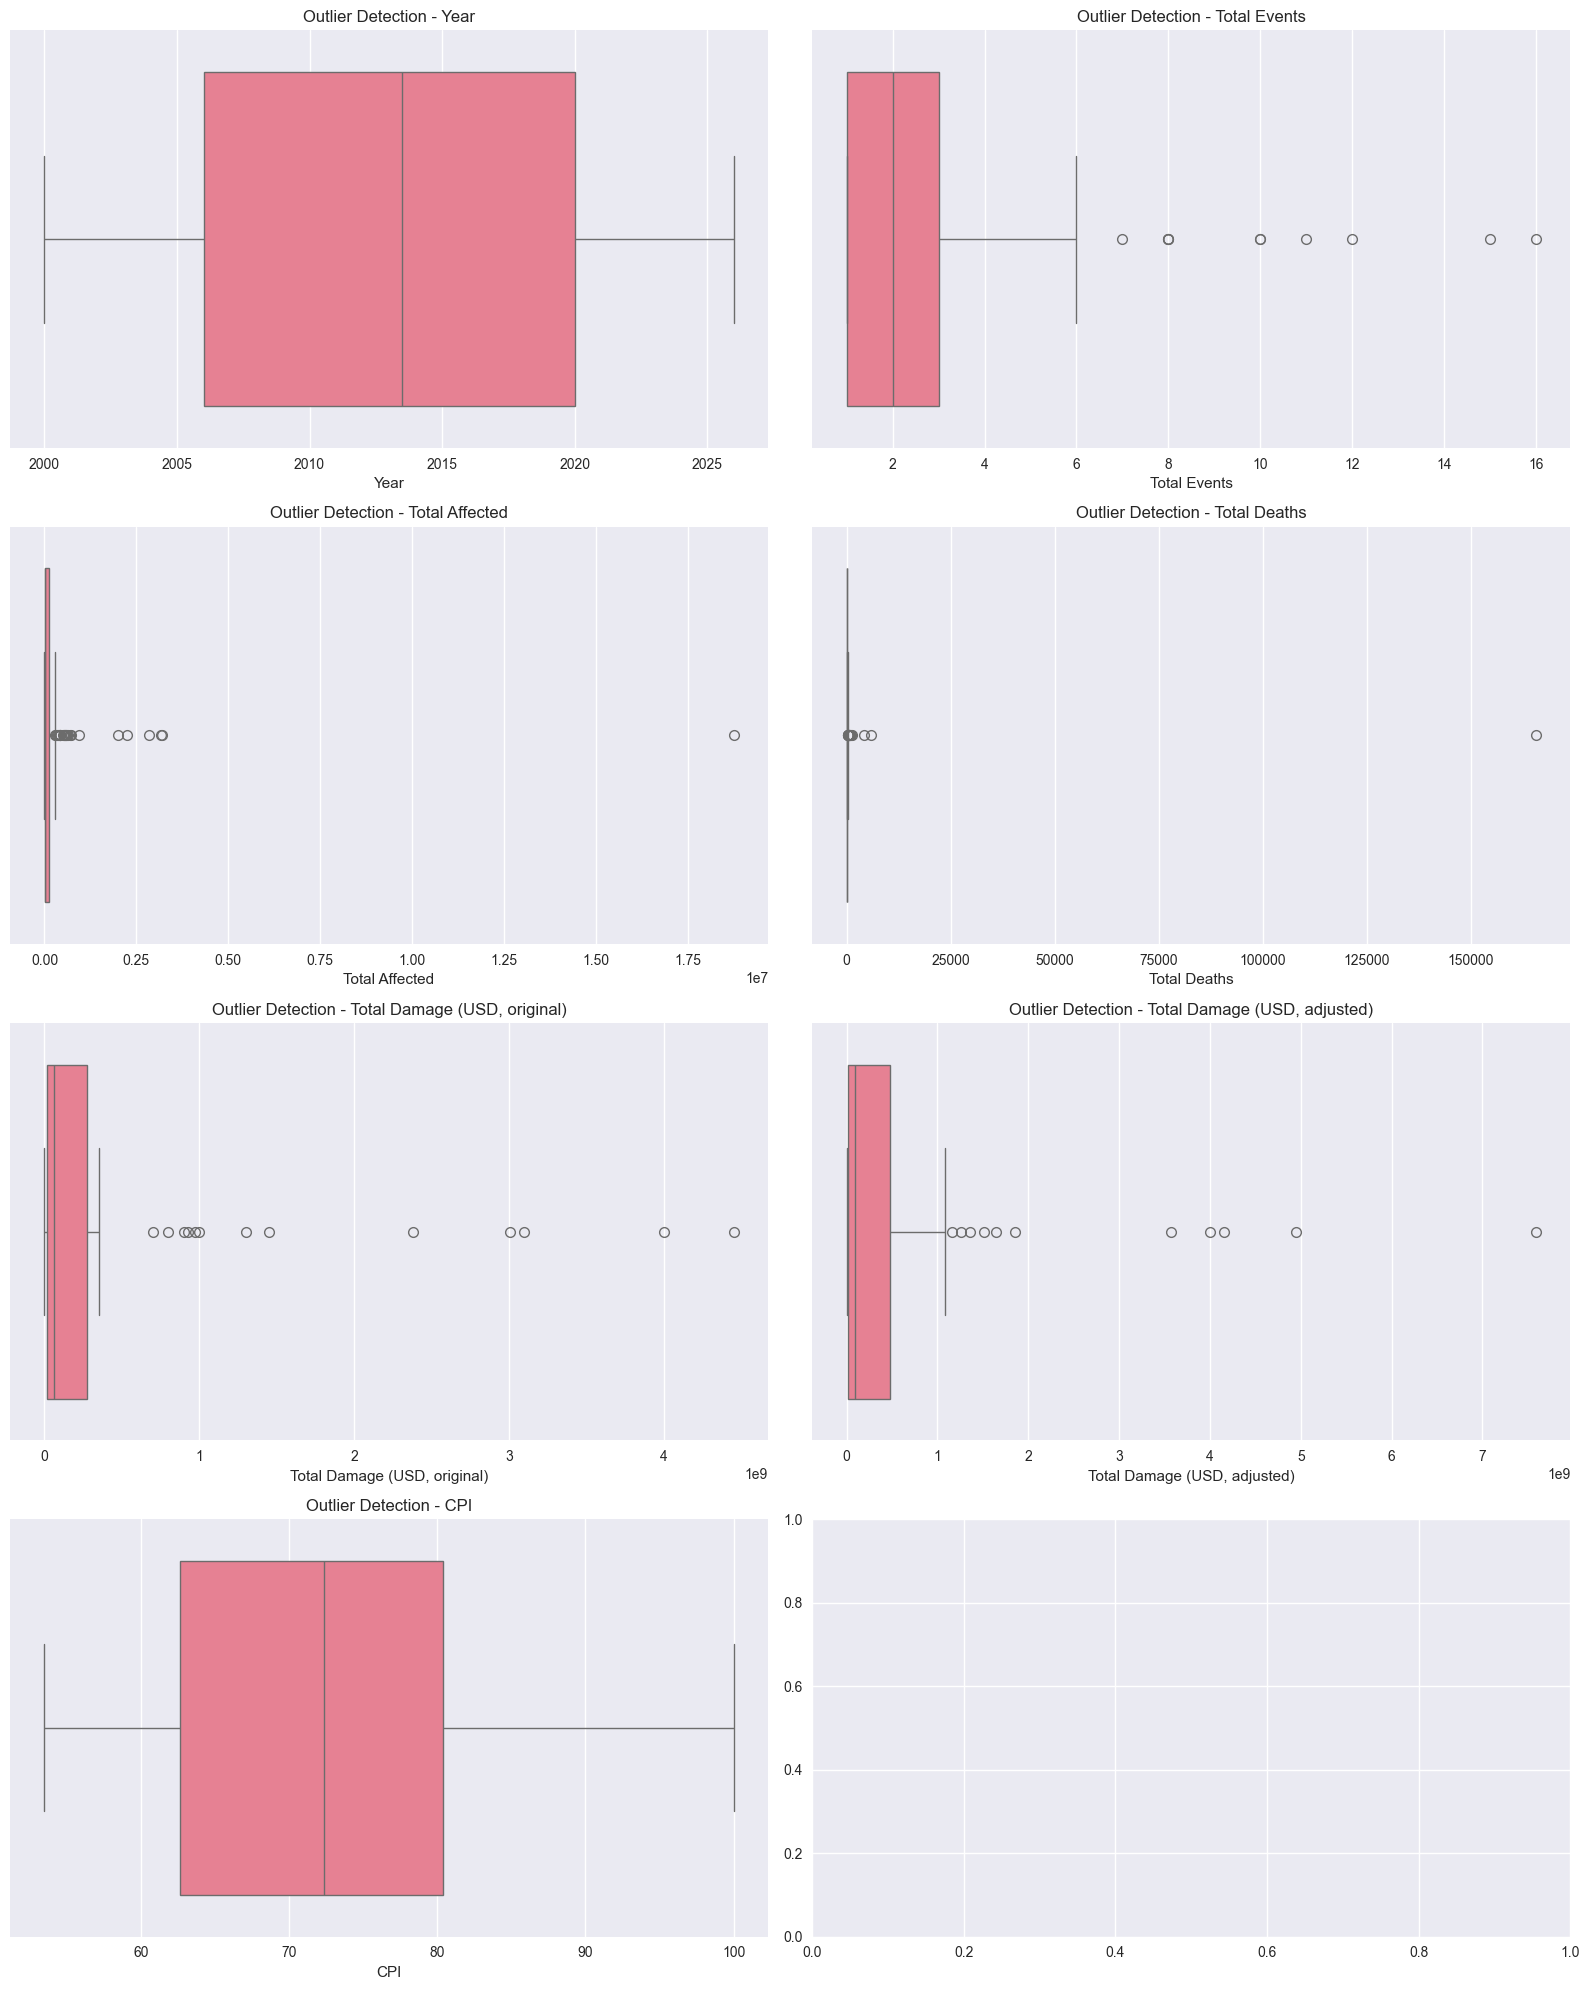

In [38]:
print("\n NUMERICAL FEATURE ANALYSIS")
print("="*40)

# Distribution
numeric_cols = df.select_dtypes(
    include=np.number
).columns

fig, axes = plt.subplots(
    len(numeric_cols)//2+1,
    2,
    figsize=(16,20)
)

axes = axes.flatten()

for i,col in enumerate(numeric_cols):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {col}"
    )

plt.tight_layout()

plt.savefig(
    '../reports/figures/2_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Boxplot Outlier
fig, axes = plt.subplots(
    len(numeric_cols)//2+1,
    2,
    figsize=(16,20)
)

axes = axes.flatten()

for i,col in enumerate(numeric_cols):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(
        f"Outlier Detection - {col}"
    )

plt.tight_layout()

plt.savefig(
    '../reports/figures/3_boxplot_outlier.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


 CATEGORICAL ANALYSIS


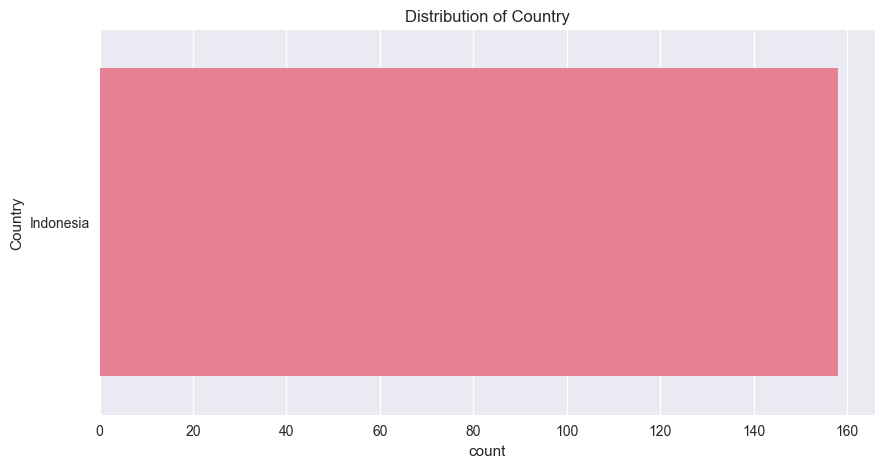

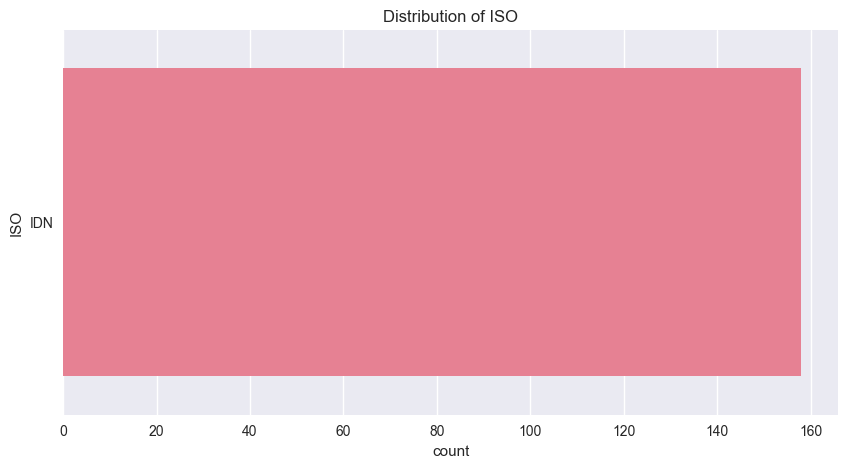

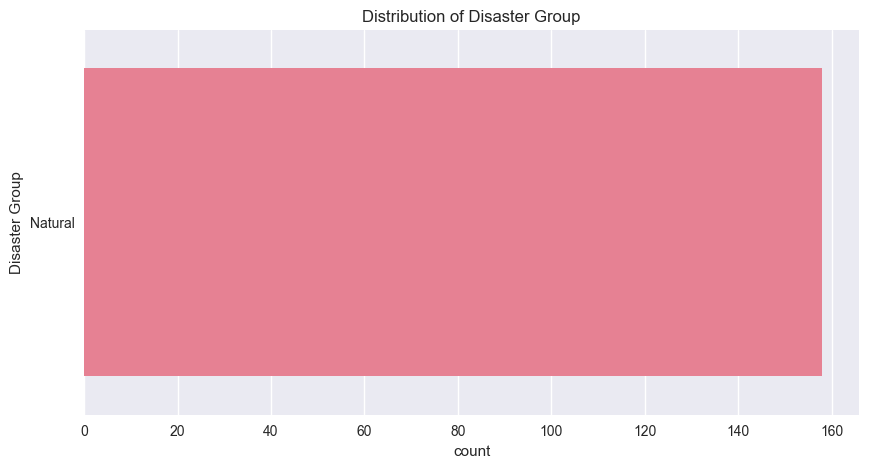

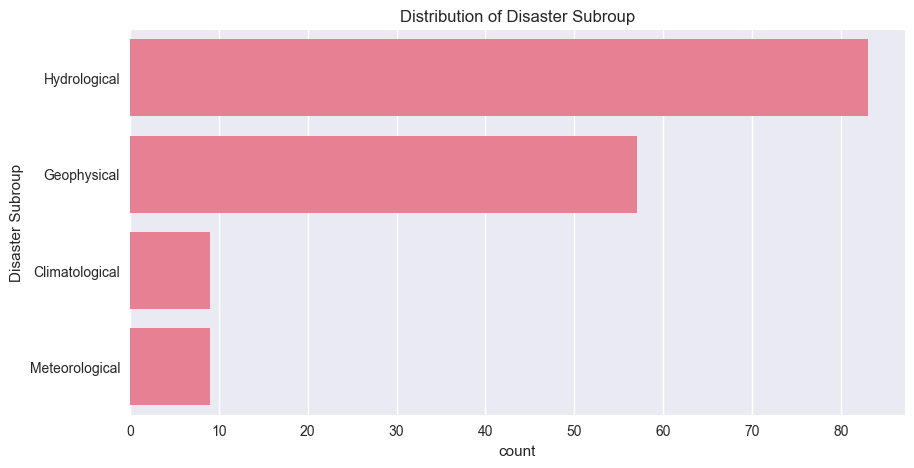

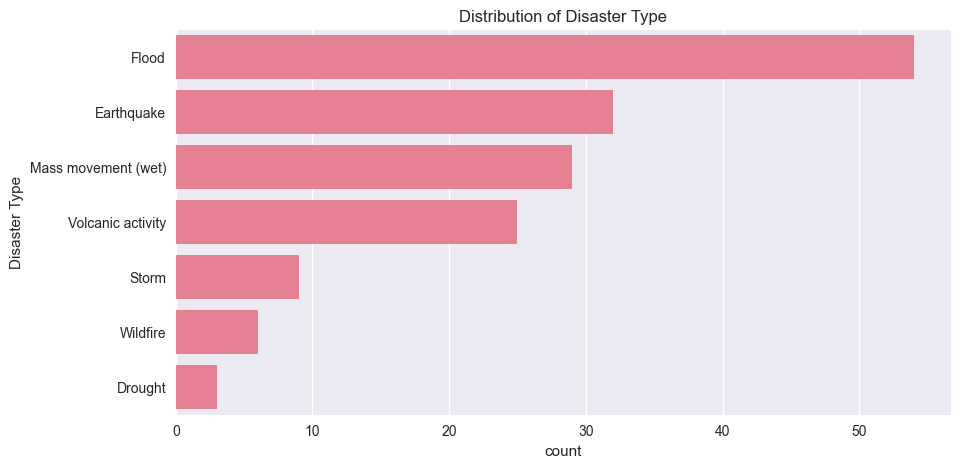

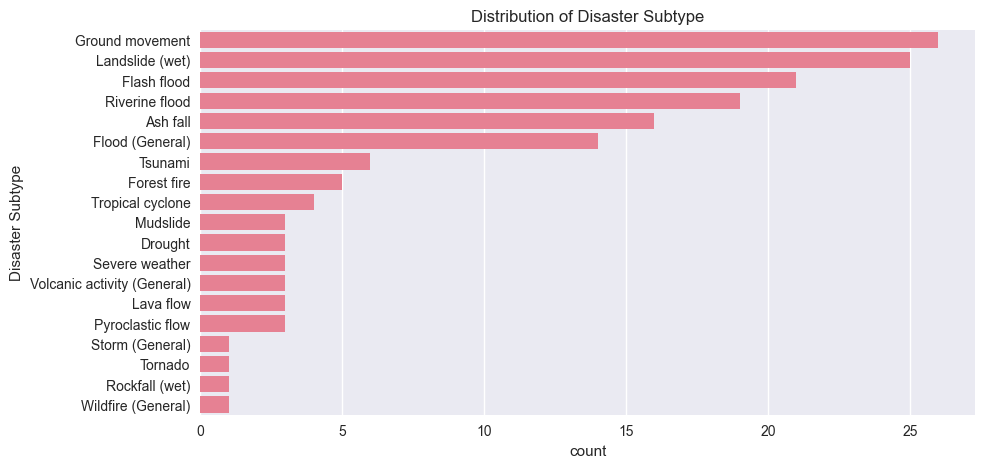

In [39]:
print("\n CATEGORICAL ANALYSIS")
print("="*40)

cat_cols = df.select_dtypes(
    include="object"
).columns

for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.savefig(
    '../reports/figures/4_categorical_analysis.png',
    dpi=300,
    bbox_inches='tight'
)
    
    plt.show()


 CORRELATION ANALYSIS


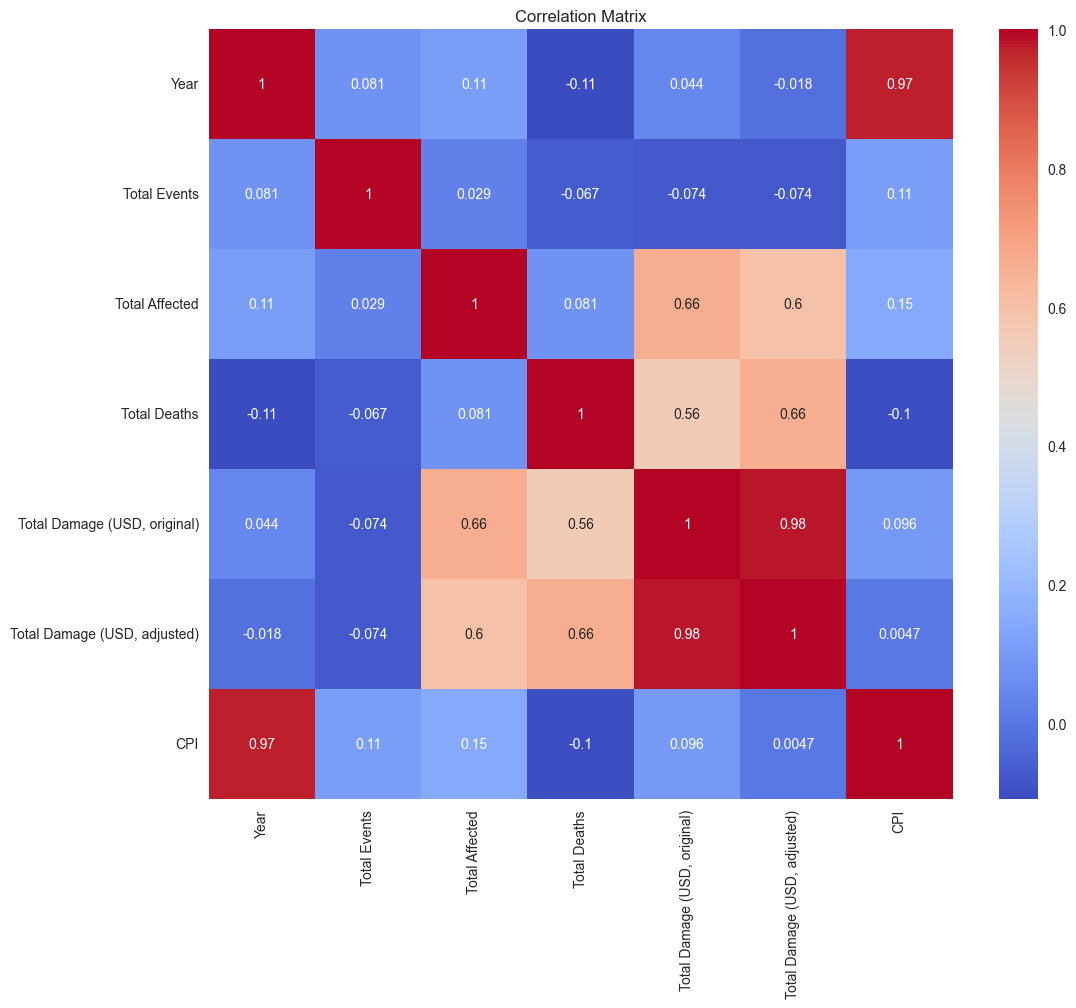

In [40]:
print("\n CORRELATION ANALYSIS")
print("="*40)

plt.figure(figsize=(12,10))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.savefig(
    '../reports/figures/5_correlation_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


 DISASTER IMPACT ANALYSIS


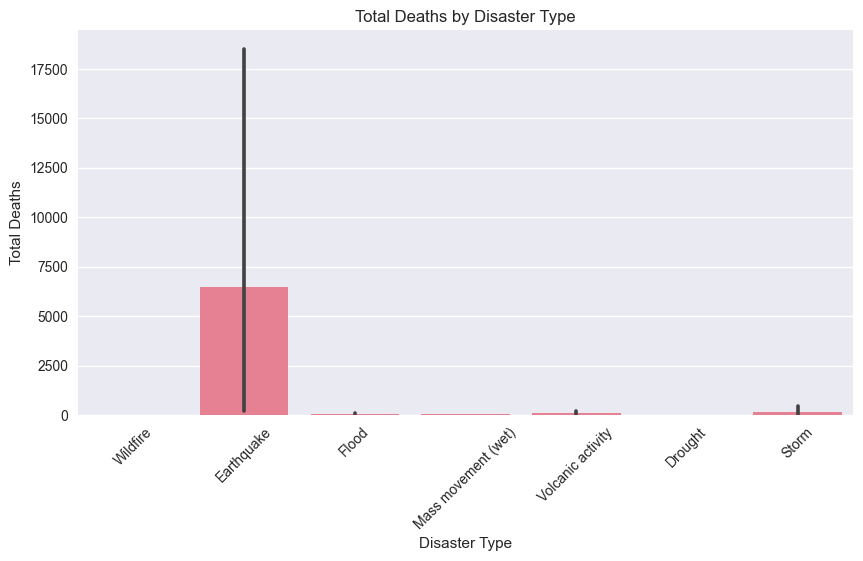

In [41]:
print("\n DISASTER IMPACT ANALYSIS")
print("="*40)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Disaster Type',
    y='Total Deaths'
)

plt.xticks(rotation=45)

plt.title(
    "Total Deaths by Disaster Type"
)

plt.savefig(
    '../reports/figures/6_total_deaths_by_disaster_type.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [42]:
print("\n💡 KEY INSIGHTS")
print("="*40)

print(
    f"Total Disaster Types : {df['Disaster Type'].nunique()}"
)

print(
    f"Highest Deaths : {df['Total Deaths'].max()}"
)

print(
    f"Highest Affected : {df['Total Affected'].max()}"
)


💡 KEY INSIGHTS
Total Disaster Types : 7
Highest Deaths : 165708.0
Highest Affected : 18750000.0
